In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv("D:/FLIGHT PRICE PREDICTOR/final_5.8M_flight_dataset.csv", low_memory=False)

In [3]:
airline = pd.read_csv('D:/FLIGHT PRICE PREDICTOR/flight/airlines.csv')
airport = pd.read_csv('D:/FLIGHT PRICE PREDICTOR/flight/airports.csv')

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 32 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [6]:
df.describe()


,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,FARE
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,5.819073e+06,5.714008e+06,5.714008e+06,5.819079e+06,5.726566e+06,5.726566e+06,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,5.819079e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,1.416859e+02,1.370062e+02,1.135116e+02,8.223565e+02,1.471469e+03,7.434971e+00,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00,1.735065e+02
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,7.521058e+01,7.421107e+01,7.223082e+01,6.077843e+02,5.221879e+02,5.638548e+00,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01,9.202528e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,1.800000e+01,1.400000e+01,7.000000e+00,2.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.900000e+01
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,8.500000e+01,8.200000e+01,6.000000e+01,3.730000e+02,1.054000e+03,4.000000e+00,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.065500e+02
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,1.230000e+02,1.180000e+02,9.400000e+01,6.470000e+02,1.509000e+03,6.000000e+00,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00,1.496600e+02
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,1.730000e+02,1.680000e+02,1.440000e+02,1.062000e+03,1.911000e+03,9.000000e+00,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00,2.102100e+02
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,7.180000e+02,7.660000e+02,6.900000e+02,4.983000e+03,2.400000e+03,2.480000e+02,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03,8.892300e+02


In [7]:
df.isnull().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
FARE                         0
dtype: i

In [8]:
Missing_percentage = (df.isnull().sum()/df.shape[0])*100
print(np.round(Missing_percentage, decimals=2))

YEAR                    0.00
MONTH                   0.00
DAY                     0.00
DAY_OF_WEEK             0.00
AIRLINE                 0.00
FLIGHT_NUMBER           0.00
TAIL_NUMBER             0.25
ORIGIN_AIRPORT          0.00
DESTINATION_AIRPORT     0.00
SCHEDULED_DEPARTURE     0.00
DEPARTURE_TIME          1.48
DEPARTURE_DELAY         1.48
TAXI_OUT                1.53
WHEELS_OFF              1.53
SCHEDULED_TIME          0.00
ELAPSED_TIME            1.81
AIR_TIME                1.81
DISTANCE                0.00
WHEELS_ON               1.59
TAXI_IN                 1.59
SCHEDULED_ARRIVAL       0.00
ARRIVAL_TIME            1.59
ARRIVAL_DELAY           1.81
DIVERTED                0.00
CANCELLED               0.00
CANCELLATION_REASON    98.46
AIR_SYSTEM_DELAY       81.72
SECURITY_DELAY         81.72
AIRLINE_DELAY          81.72
LATE_AIRCRAFT_DELAY    81.72
WEATHER_DELAY          81.72
FARE                    0.00
dtype: float64


In [9]:
df["YEAR"].unique()
df.drop(columns=['YEAR'], inplace=True)

In [10]:
df['MONTH'].unique()
df['DAY_OF_WEEK'].unique()
df['AIRLINE'].value_counts()


AIRLINE
WN    1261855
DL     875881
AA     725984
OO     588353
EV     571977
UA     515723
MQ     294632
B6     267048
US     198715
AS     172521
NK     117379
F9      90836
HA      76272
VX      61903
Name: count, dtype: int64

In [11]:
df.head()

,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,FARE
0,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,266.42
1,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,403.17
2,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,393.75
3,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,401.98
4,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,267.21


In [12]:
df = df[df['CANCELLED'] != 1]
df.drop(df[df['CANCELLED'] == 1].index, inplace=True)

In [13]:
df = df[df['DIVERTED'] != 1]
df.drop(df[df['DIVERTED'] == 1].index, inplace=True)

In [14]:
df.head()

,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,FARE
0,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,266.42
1,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,403.17
2,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,393.75
3,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,401.98
4,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,267.21


In [15]:
df.drop(df[df['CANCELLED'] == 1].index, inplace=True)
df.drop(df[df['DIVERTED'] == 1].index, inplace=True)

In [16]:
df.drop(columns=['CANCELLED', 'DIVERTED'], inplace=True)

In [17]:
df.head()

,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,FARE
0,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,NaN,NaN,NaN,NaN,NaN,NaN,266.42
1,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,NaN,NaN,NaN,NaN,NaN,NaN,403.17
2,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,393.75
3,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,NaN,NaN,NaN,NaN,NaN,NaN,401.98
4,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,NaN,NaN,NaN,NaN,NaN,NaN,267.21


In [18]:
df['MONTH'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [19]:
df['DAY_OF_WEEK'].unique()

array([4, 5, 6, 7, 1, 2, 3])

In [20]:
df['AIRLINE'].nunique()

14

In [21]:
df['ORIGIN_AIRPORT'].nunique()

628

In [22]:
df['DESTINATION_AIRPORT'].nunique()

629

In [23]:
df['FARE'].describe()

count    5.714008e+06
mean     1.738205e+02
std      9.214844e+01
min      3.900000e+01
25%      1.067800e+02
50%      1.499200e+02
75%      2.104200e+02
max      8.892300e+02
Name: FARE, dtype: float64

In [24]:
df = df.merge(
    airline,
    left_on="AIRLINE",
    right_on="IATA_CODE",
    how="left"
)

In [25]:
df['AIRLINE_y'].isnull().sum()

np.int64(0)

In [26]:
df.head()

,MONTH,DAY,DAY_OF_WEEK,AIRLINE_x,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,FARE,IATA_CODE,AIRLINE_y
0,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,NaN,NaN,NaN,NaN,NaN,NaN,266.42,AS,Alaska Airlines Inc.
1,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,NaN,NaN,NaN,NaN,NaN,NaN,403.17,AA,American Airlines Inc.
2,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,393.75,US,US Airways Inc.
3,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,NaN,NaN,NaN,NaN,NaN,NaN,401.98,AA,American Airlines Inc.
4,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,NaN,NaN,NaN,NaN,NaN,NaN,267.21,AS,Alaska Airlines Inc.


In [27]:
df.drop(columns=[ 'IATA_CODE'], inplace=True)

In [28]:
df.head(50)

,MONTH,DAY,DAY_OF_WEEK,AIRLINE_x,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,FARE,AIRLINE_y
0,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,NaN,NaN,NaN,NaN,NaN,NaN,266.42,Alaska Airlines Inc.
1,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,NaN,NaN,NaN,NaN,NaN,NaN,403.17,American Airlines Inc.
2,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,393.75,US Airways Inc.
3,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,NaN,NaN,NaN,NaN,NaN,NaN,401.98,American Airlines Inc.
4,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,NaN,NaN,NaN,NaN,NaN,NaN,267.21,Alaska Airlines Inc.
5,1,1,4,DL,806,N3730B,SFO,MSP,25,20.0,-5.0,18.0,38.0,217.0,230.0,206.0,1589,604.0,6.0,602,610.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,288.16,Delta Air Lines Inc.
6,1,1,4,NK,612,N635NK,LAS,MSP,25,19.0,-6.0,11.0,30.0,181.0,170.0,154.0,1299,504.0,5.0,526,509.0,-17.0,NaN,NaN,NaN,NaN,NaN,NaN,247.22,Spirit Air Lines
7,1,1,4,US,2013,N584UW,LAX,CLT,30,44.0,14.0,13.0,57.0,273.0,249.0,228.0,2125,745.0,8.0,803,753.0,-10.0,NaN,NaN,NaN,NaN,NaN,NaN,368.38,US Airways Inc.
8,1,1,4,AA,1112,N3LAAA,SFO,DFW,30,19.0,-11.0,17.0,36.0,195.0,193.0,173.0,1464,529.0,3.0,545,532.0,-13.0,NaN,NaN,NaN,NaN,NaN,NaN,269.36,American Airlines Inc.
9,1,1,4,DL,1173,N826DN,LAS,ATL,30,33.0,3.0,12.0,45.0,221.0,203.0,186.0,1747,651.0,5.0,711,656.0,-15.0,NaN,NaN,NaN,NaN,NaN,NaN,312.09,Delta Air Lines Inc.


In [29]:
df.rename(columns={"AIRLINE_y": "AIRLINE"}, inplace=True)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5714008 entries, 0 to 5714007
Data columns (total 30 columns):
 #   Column               Dtype  
---  ------               -----  
 0   MONTH                int64  
 1   DAY                  int64  
 2   DAY_OF_WEEK          int64  
 3   AIRLINE_x            object 
 4   FLIGHT_NUMBER        int64  
 5   TAIL_NUMBER          object 
 6   ORIGIN_AIRPORT       object 
 7   DESTINATION_AIRPORT  object 
 8   SCHEDULED_DEPARTURE  int64  
 9   DEPARTURE_TIME       float64
 10  DEPARTURE_DELAY      float64
 11  TAXI_OUT             float64
 12  WHEELS_OFF           float64
 13  SCHEDULED_TIME       float64
 14  ELAPSED_TIME         float64
 15  AIR_TIME             float64
 16  DISTANCE             int64  
 17  WHEELS_ON            float64
 18  TAXI_IN              float64
 19  SCHEDULED_ARRIVAL    int64  
 20  ARRIVAL_TIME         float64
 21  ARRIVAL_DELAY        float64
 22  CANCELLATION_REASON  object 
 23  AIR_SYSTEM_DELAY     float64
 24

In [31]:
df.drop(columns=['AIRLINE_DELAY','AIR_SYSTEM_DELAY','WEATHER_DELAY','LATE_AIRCRAFT_DELAY','SECURITY_DELAY','CANCELLATION_REASON', 'ARRIVAL_DELAY','TAXI_IN','WHEELS_ON','WHEELS_OFF','DEPARTURE_DELAY','TAIL_NUMBER','FLIGHT_NUMBER' ], inplace=True )

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5714008 entries, 0 to 5714007
Data columns (total 17 columns):
 #   Column               Dtype  
---  ------               -----  
 0   MONTH                int64  
 1   DAY                  int64  
 2   DAY_OF_WEEK          int64  
 3   AIRLINE_x            object 
 4   ORIGIN_AIRPORT       object 
 5   DESTINATION_AIRPORT  object 
 6   SCHEDULED_DEPARTURE  int64  
 7   DEPARTURE_TIME       float64
 8   TAXI_OUT             float64
 9   SCHEDULED_TIME       float64
 10  ELAPSED_TIME         float64
 11  AIR_TIME             float64
 12  DISTANCE             int64  
 13  SCHEDULED_ARRIVAL    int64  
 14  ARRIVAL_TIME         float64
 15  FARE                 float64
 16  AIRLINE              object 
dtypes: float64(7), int64(6), object(4)
memory usage: 741.1+ MB


In [33]:
df.head(50)

,MONTH,DAY,DAY_OF_WEEK,AIRLINE_x,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,TAXI_OUT,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_TIME,FARE,AIRLINE
0,1,1,4,AS,ANC,SEA,5,2354.0,21.0,205.0,194.0,169.0,1448,430,408.0,266.42,Alaska Airlines Inc.
1,1,1,4,AA,LAX,PBI,10,2.0,12.0,280.0,279.0,263.0,2330,750,741.0,403.17,American Airlines Inc.
2,1,1,4,US,SFO,CLT,20,18.0,16.0,286.0,293.0,266.0,2296,806,811.0,393.75,US Airways Inc.
3,1,1,4,AA,LAX,MIA,20,15.0,15.0,285.0,281.0,258.0,2342,805,756.0,401.98,American Airlines Inc.
4,1,1,4,AS,SEA,ANC,25,24.0,11.0,235.0,215.0,199.0,1448,320,259.0,267.21,Alaska Airlines Inc.
5,1,1,4,DL,SFO,MSP,25,20.0,18.0,217.0,230.0,206.0,1589,602,610.0,288.16,Delta Air Lines Inc.
6,1,1,4,NK,LAS,MSP,25,19.0,11.0,181.0,170.0,154.0,1299,526,509.0,247.22,Spirit Air Lines
7,1,1,4,US,LAX,CLT,30,44.0,13.0,273.0,249.0,228.0,2125,803,753.0,368.38,US Airways Inc.
8,1,1,4,AA,SFO,DFW,30,19.0,17.0,195.0,193.0,173.0,1464,545,532.0,269.36,American Airlines Inc.
9,1,1,4,DL,LAS,ATL,30,33.0,12.0,221.0,203.0,186.0,1747,711,656.0,312.09,Delta Air Lines Inc.


In [34]:
df.describe()

,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DEPARTURE_TIME,TAXI_OUT,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_TIME,FARE
count,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06
mean,6.547799e+00,1.570759e+01,3.932643e+00,1.328907e+03,1.335066e+03,1.606550e+01,1.418940e+02,1.370062e+02,1.135116e+02,8.244569e+02,1.493187e+03,1.476373e+03,1.738205e+02
std,3.397421e+00,8.774394e+00,1.985967e+00,4.835251e+02,4.964198e+02,8.882449e+00,7.531400e+01,7.421107e+01,7.223082e+01,6.086620e+02,5.069011e+02,5.259730e+02,9.214844e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.800000e+01,1.400000e+01,7.000000e+00,3.100000e+01,1.000000e+00,1.000000e+00,3.900000e+01
25%,4.000000e+00,8.000000e+00,2.000000e+00,9.160000e+02,9.210000e+02,1.100000e+01,8.500000e+01,8.200000e+01,6.000000e+01,3.730000e+02,1.110000e+03,1.058000e+03,1.067800e+02
50%,7.000000e+00,1.600000e+01,4.000000e+00,1.325000e+03,1.330000e+03,1.400000e+01,1.230000e+02,1.180000e+02,9.400000e+01,6.500000e+02,1.520000e+03,1.512000e+03,1.499200e+02
75%,9.000000e+00,2.300000e+01,6.000000e+00,1.730000e+03,1.740000e+03,1.900000e+01,1.740000e+02,1.680000e+02,1.440000e+02,1.065000e+03,1.917000e+03,1.916000e+03,2.104200e+02
max,1.200000e+01,3.100000e+01,7.000000e+00,2.359000e+03,2.400000e+03,2.250000e+02,7.180000e+02,7.660000e+02,6.900000e+02,4.983000e+03,2.400000e+03,2.400000e+03,8.892300e+02


In [35]:
Missing_percentage = (df.isnull().sum()/df.shape[0])*100
print(np.round(Missing_percentage, decimals=2))

MONTH                  0.0
DAY                    0.0
DAY_OF_WEEK            0.0
AIRLINE_x              0.0
ORIGIN_AIRPORT         0.0
DESTINATION_AIRPORT    0.0
SCHEDULED_DEPARTURE    0.0
DEPARTURE_TIME         0.0
TAXI_OUT               0.0
SCHEDULED_TIME         0.0
ELAPSED_TIME           0.0
AIR_TIME               0.0
DISTANCE               0.0
SCHEDULED_ARRIVAL      0.0
ARRIVAL_TIME           0.0
FARE                   0.0
AIRLINE                0.0
dtype: float64


In [36]:
df.shape

(5714008, 17)

In [37]:
df["DEP_HOUR"] = df["SCHEDULED_DEPARTURE"] // 100

In [38]:
df["ARR_HOUR"] = df["SCHEDULED_ARRIVAL"] // 100

In [39]:
df["DEP_MIN"] = df["SCHEDULED_DEPARTURE"] % 100

In [40]:
df["ARR_MIN"] = df["SCHEDULED_ARRIVAL"] % 100

In [41]:
df["IS_WEEKEND"] = df["DAY_OF_WEEK"].apply(lambda x: 1 if x in [6,7] else 0)

In [42]:
df["ROUTE"] = df["ORIGIN_AIRPORT"] + "_" + df["DESTINATION_AIRPORT"]

In [43]:
df.head(50)

,MONTH,DAY,DAY_OF_WEEK,AIRLINE_x,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,TAXI_OUT,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_TIME,FARE,AIRLINE,DEP_HOUR,ARR_HOUR,DEP_MIN,ARR_MIN,IS_WEEKEND,ROUTE
0,1,1,4,AS,ANC,SEA,5,2354.0,21.0,205.0,194.0,169.0,1448,430,408.0,266.42,Alaska Airlines Inc.,0,4,5,30,0,ANC_SEA
1,1,1,4,AA,LAX,PBI,10,2.0,12.0,280.0,279.0,263.0,2330,750,741.0,403.17,American Airlines Inc.,0,7,10,50,0,LAX_PBI
2,1,1,4,US,SFO,CLT,20,18.0,16.0,286.0,293.0,266.0,2296,806,811.0,393.75,US Airways Inc.,0,8,20,6,0,SFO_CLT
3,1,1,4,AA,LAX,MIA,20,15.0,15.0,285.0,281.0,258.0,2342,805,756.0,401.98,American Airlines Inc.,0,8,20,5,0,LAX_MIA
4,1,1,4,AS,SEA,ANC,25,24.0,11.0,235.0,215.0,199.0,1448,320,259.0,267.21,Alaska Airlines Inc.,0,3,25,20,0,SEA_ANC
5,1,1,4,DL,SFO,MSP,25,20.0,18.0,217.0,230.0,206.0,1589,602,610.0,288.16,Delta Air Lines Inc.,0,6,25,2,0,SFO_MSP
6,1,1,4,NK,LAS,MSP,25,19.0,11.0,181.0,170.0,154.0,1299,526,509.0,247.22,Spirit Air Lines,0,5,25,26,0,LAS_MSP
7,1,1,4,US,LAX,CLT,30,44.0,13.0,273.0,249.0,228.0,2125,803,753.0,368.38,US Airways Inc.,0,8,30,3,0,LAX_CLT
8,1,1,4,AA,SFO,DFW,30,19.0,17.0,195.0,193.0,173.0,1464,545,532.0,269.36,American Airlines Inc.,0,5,30,45,0,SFO_DFW
9,1,1,4,DL,LAS,ATL,30,33.0,12.0,221.0,203.0,186.0,1747,711,656.0,312.09,Delta Air Lines Inc.,0,7,30,11,0,LAS_ATL


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5714008 entries, 0 to 5714007
Data columns (total 23 columns):
 #   Column               Dtype  
---  ------               -----  
 0   MONTH                int64  
 1   DAY                  int64  
 2   DAY_OF_WEEK          int64  
 3   AIRLINE_x            object 
 4   ORIGIN_AIRPORT       object 
 5   DESTINATION_AIRPORT  object 
 6   SCHEDULED_DEPARTURE  int64  
 7   DEPARTURE_TIME       float64
 8   TAXI_OUT             float64
 9   SCHEDULED_TIME       float64
 10  ELAPSED_TIME         float64
 11  AIR_TIME             float64
 12  DISTANCE             int64  
 13  SCHEDULED_ARRIVAL    int64  
 14  ARRIVAL_TIME         float64
 15  FARE                 float64
 16  AIRLINE              object 
 17  DEP_HOUR             int64  
 18  ARR_HOUR             int64  
 19  DEP_MIN              int64  
 20  ARR_MIN              int64  
 21  IS_WEEKEND           int64  
 22  ROUTE                object 
dtypes: float64(7), int64(11), object

In [45]:
cols_to_drop = [
"TAXI_OUT",
"ELAPSED_TIME",
"AIR_TIME",
"SCHEDULED_DEPARTURE",
"SCHEDULED_ARRIVAL"
]

df.drop(columns=cols_to_drop, inplace=True)

In [46]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5714008 entries, 0 to 5714007
Data columns (total 18 columns):
 #   Column               Dtype  
---  ------               -----  
 0   MONTH                int64  
 1   DAY                  int64  
 2   DAY_OF_WEEK          int64  
 3   AIRLINE_x            object 
 4   ORIGIN_AIRPORT       object 
 5   DESTINATION_AIRPORT  object 
 6   DEPARTURE_TIME       float64
 7   SCHEDULED_TIME       float64
 8   DISTANCE             int64  
 9   ARRIVAL_TIME         float64
 10  FARE                 float64
 11  AIRLINE              object 
 12  DEP_HOUR             int64  
 13  ARR_HOUR             int64  
 14  DEP_MIN              int64  
 15  ARR_MIN              int64  
 16  IS_WEEKEND           int64  
 17  ROUTE                object 
dtypes: float64(4), int64(9), object(5)
memory usage: 784.7+ MB


In [47]:
df.head(10)

,MONTH,DAY,DAY_OF_WEEK,AIRLINE_x,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DEPARTURE_TIME,SCHEDULED_TIME,DISTANCE,ARRIVAL_TIME,FARE,AIRLINE,DEP_HOUR,ARR_HOUR,DEP_MIN,ARR_MIN,IS_WEEKEND,ROUTE
0,1,1,4,AS,ANC,SEA,2354.0,205.0,1448,408.0,266.42,Alaska Airlines Inc.,0,4,5,30,0,ANC_SEA
1,1,1,4,AA,LAX,PBI,2.0,280.0,2330,741.0,403.17,American Airlines Inc.,0,7,10,50,0,LAX_PBI
2,1,1,4,US,SFO,CLT,18.0,286.0,2296,811.0,393.75,US Airways Inc.,0,8,20,6,0,SFO_CLT
3,1,1,4,AA,LAX,MIA,15.0,285.0,2342,756.0,401.98,American Airlines Inc.,0,8,20,5,0,LAX_MIA
4,1,1,4,AS,SEA,ANC,24.0,235.0,1448,259.0,267.21,Alaska Airlines Inc.,0,3,25,20,0,SEA_ANC
5,1,1,4,DL,SFO,MSP,20.0,217.0,1589,610.0,288.16,Delta Air Lines Inc.,0,6,25,2,0,SFO_MSP
6,1,1,4,NK,LAS,MSP,19.0,181.0,1299,509.0,247.22,Spirit Air Lines,0,5,25,26,0,LAS_MSP
7,1,1,4,US,LAX,CLT,44.0,273.0,2125,753.0,368.38,US Airways Inc.,0,8,30,3,0,LAX_CLT
8,1,1,4,AA,SFO,DFW,19.0,195.0,1464,532.0,269.36,American Airlines Inc.,0,5,30,45,0,SFO_DFW
9,1,1,4,DL,LAS,ATL,33.0,221.0,1747,656.0,312.09,Delta Air Lines Inc.,0,7,30,11,0,LAS_ATL


In [48]:
df.drop(columns = ['DEPARTURE_TIME', 'ARRIVAL_TIME'], inplace=True)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5714008 entries, 0 to 5714007
Data columns (total 16 columns):
 #   Column               Dtype  
---  ------               -----  
 0   MONTH                int64  
 1   DAY                  int64  
 2   DAY_OF_WEEK          int64  
 3   AIRLINE_x            object 
 4   ORIGIN_AIRPORT       object 
 5   DESTINATION_AIRPORT  object 
 6   SCHEDULED_TIME       float64
 7   DISTANCE             int64  
 8   FARE                 float64
 9   AIRLINE              object 
 10  DEP_HOUR             int64  
 11  ARR_HOUR             int64  
 12  DEP_MIN              int64  
 13  ARR_MIN              int64  
 14  IS_WEEKEND           int64  
 15  ROUTE                object 
dtypes: float64(2), int64(9), object(5)
memory usage: 697.5+ MB


In [50]:
df['AIRLINE'].value_counts()

AIRLINE
Southwest Airlines Co.          1242403
Delta Air Lines Inc.             870275
American Airlines Inc.           712935
Skywest Airlines Inc.            576814
Atlantic Southeast Airlines      554752
United Air Lines Inc.            507762
American Eagle Airlines Inc.     278791
JetBlue Airways                  262042
US Airways Inc.                  194223
Alaska Airlines Inc.             171439
Spirit Air Lines                 115193
Frontier Airlines Inc.            90090
Hawaiian Airlines Inc.            76041
Virgin America                    61248
Name: count, dtype: int64

In [51]:
df.drop("AIRLINE_x", axis=1, inplace=True)

In [52]:
df.head(10)

,MONTH,DAY,DAY_OF_WEEK,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_TIME,DISTANCE,FARE,AIRLINE,DEP_HOUR,ARR_HOUR,DEP_MIN,ARR_MIN,IS_WEEKEND,ROUTE
0,1,1,4,ANC,SEA,205.0,1448,266.42,Alaska Airlines Inc.,0,4,5,30,0,ANC_SEA
1,1,1,4,LAX,PBI,280.0,2330,403.17,American Airlines Inc.,0,7,10,50,0,LAX_PBI
2,1,1,4,SFO,CLT,286.0,2296,393.75,US Airways Inc.,0,8,20,6,0,SFO_CLT
3,1,1,4,LAX,MIA,285.0,2342,401.98,American Airlines Inc.,0,8,20,5,0,LAX_MIA
4,1,1,4,SEA,ANC,235.0,1448,267.21,Alaska Airlines Inc.,0,3,25,20,0,SEA_ANC
5,1,1,4,SFO,MSP,217.0,1589,288.16,Delta Air Lines Inc.,0,6,25,2,0,SFO_MSP
6,1,1,4,LAS,MSP,181.0,1299,247.22,Spirit Air Lines,0,5,25,26,0,LAS_MSP
7,1,1,4,LAX,CLT,273.0,2125,368.38,US Airways Inc.,0,8,30,3,0,LAX_CLT
8,1,1,4,SFO,DFW,195.0,1464,269.36,American Airlines Inc.,0,5,30,45,0,SFO_DFW
9,1,1,4,LAS,ATL,221.0,1747,312.09,Delta Air Lines Inc.,0,7,30,11,0,LAS_ATL


In [53]:
def dep_time_bin(hour):
    if hour <= 5:
        return "Early_Morning"
    elif hour <= 11:
        return "Morning"
    elif hour <= 17:
        return "Afternoon"
    else:
        return "Evening_Night"

df["DEP_TIME_BIN"] = df["DEP_HOUR"].apply(dep_time_bin)

In [54]:
df["IS_HOLIDAY_SEASON"] = df["MONTH"].apply(lambda x: 1 if x in [6,7,11,12] else 0)

In [55]:
df["FARE_PER_MILE"] = df["FARE"] / df["DISTANCE"]

In [56]:
df.head(10)

,MONTH,DAY,DAY_OF_WEEK,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_TIME,DISTANCE,FARE,AIRLINE,DEP_HOUR,ARR_HOUR,DEP_MIN,ARR_MIN,IS_WEEKEND,ROUTE,DEP_TIME_BIN,IS_HOLIDAY_SEASON,FARE_PER_MILE
0,1,1,4,ANC,SEA,205.0,1448,266.42,Alaska Airlines Inc.,0,4,5,30,0,ANC_SEA,Early_Morning,0,0.183992
1,1,1,4,LAX,PBI,280.0,2330,403.17,American Airlines Inc.,0,7,10,50,0,LAX_PBI,Early_Morning,0,0.173034
2,1,1,4,SFO,CLT,286.0,2296,393.75,US Airways Inc.,0,8,20,6,0,SFO_CLT,Early_Morning,0,0.171494
3,1,1,4,LAX,MIA,285.0,2342,401.98,American Airlines Inc.,0,8,20,5,0,LAX_MIA,Early_Morning,0,0.171640
4,1,1,4,SEA,ANC,235.0,1448,267.21,Alaska Airlines Inc.,0,3,25,20,0,SEA_ANC,Early_Morning,0,0.184537
5,1,1,4,SFO,MSP,217.0,1589,288.16,Delta Air Lines Inc.,0,6,25,2,0,SFO_MSP,Early_Morning,0,0.181347
6,1,1,4,LAS,MSP,181.0,1299,247.22,Spirit Air Lines,0,5,25,26,0,LAS_MSP,Early_Morning,0,0.190316
7,1,1,4,LAX,CLT,273.0,2125,368.38,US Airways Inc.,0,8,30,3,0,LAX_CLT,Early_Morning,0,0.173355
8,1,1,4,SFO,DFW,195.0,1464,269.36,American Airlines Inc.,0,5,30,45,0,SFO_DFW,Early_Morning,0,0.183989
9,1,1,4,LAS,ATL,221.0,1747,312.09,Delta Air Lines Inc.,0,7,30,11,0,LAS_ATL,Early_Morning,0,0.178643


In [57]:
Q1 = df["FARE"].quantile(0.25)
Q3 = df["FARE"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["FARE"] >= lower) & (df["FARE"] <= upper)]


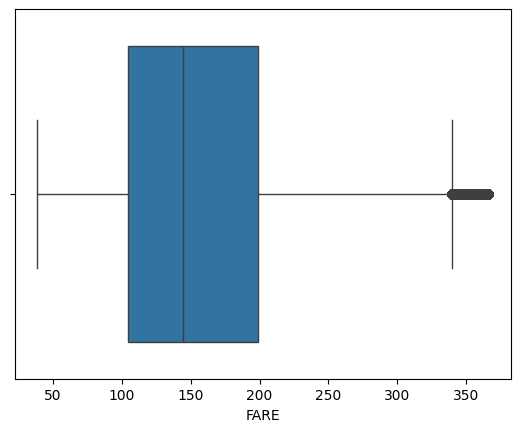

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["FARE"])
plt.show()

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5370678 entries, 0 to 5714007
Data columns (total 18 columns):
 #   Column               Dtype  
---  ------               -----  
 0   MONTH                int64  
 1   DAY                  int64  
 2   DAY_OF_WEEK          int64  
 3   ORIGIN_AIRPORT       object 
 4   DESTINATION_AIRPORT  object 
 5   SCHEDULED_TIME       float64
 6   DISTANCE             int64  
 7   FARE                 float64
 8   AIRLINE              object 
 9   DEP_HOUR             int64  
 10  ARR_HOUR             int64  
 11  DEP_MIN              int64  
 12  ARR_MIN              int64  
 13  IS_WEEKEND           int64  
 14  ROUTE                object 
 15  DEP_TIME_BIN         object 
 16  IS_HOLIDAY_SEASON    int64  
 17  FARE_PER_MILE        float64
dtypes: float64(3), int64(10), object(5)
memory usage: 778.5+ MB


In [60]:
df['ORIGIN_AIRPORT'].str.isnumeric().sum()

np.int64(454324)

In [61]:
df['ORIGIN_AIRPORT'].str.isnumeric().value_counts()

ORIGIN_AIRPORT
False    4916354
True      454324
Name: count, dtype: int64

In [62]:
df['DESTINATION_AIRPORT'].str.isnumeric().value_counts()

DESTINATION_AIRPORT
False    4916354
True      454324
Name: count, dtype: int64

In [63]:
df = df[~df["ORIGIN_AIRPORT"].str.isnumeric()]
df = df[~df["DESTINATION_AIRPORT"].str.isnumeric()]

In [64]:
df["ORIGIN_AIRPORT"].str.isnumeric().value_counts()

ORIGIN_AIRPORT
False    4916354
Name: count, dtype: int64

In [65]:
df["DESTINATION_AIRPORT"].str.isnumeric().value_counts()

DESTINATION_AIRPORT
False    4916354
Name: count, dtype: int64

In [66]:
df.shape

(4916354, 18)

In [67]:
df[(df["DEP_MIN"] > 59) | (df["ARR_MIN"] > 59)]

,MONTH,DAY,DAY_OF_WEEK,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_TIME,DISTANCE,FARE,AIRLINE,DEP_HOUR,ARR_HOUR,DEP_MIN,ARR_MIN,IS_WEEKEND,ROUTE,DEP_TIME_BIN,IS_HOLIDAY_SEASON,FARE_PER_MILE


In [68]:
df[(df["DEP_HOUR"] > 23) | (df["ARR_HOUR"] > 23)]
df = df[(df["DEP_HOUR"] <= 23) & (df["ARR_HOUR"] <= 23)]

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4916353 entries, 0 to 5714007
Data columns (total 18 columns):
 #   Column               Dtype  
---  ------               -----  
 0   MONTH                int64  
 1   DAY                  int64  
 2   DAY_OF_WEEK          int64  
 3   ORIGIN_AIRPORT       object 
 4   DESTINATION_AIRPORT  object 
 5   SCHEDULED_TIME       float64
 6   DISTANCE             int64  
 7   FARE                 float64
 8   AIRLINE              object 
 9   DEP_HOUR             int64  
 10  ARR_HOUR             int64  
 11  DEP_MIN              int64  
 12  ARR_MIN              int64  
 13  IS_WEEKEND           int64  
 14  ROUTE                object 
 15  DEP_TIME_BIN         object 
 16  IS_HOLIDAY_SEASON    int64  
 17  FARE_PER_MILE        float64
dtypes: float64(3), int64(10), object(5)
memory usage: 712.7+ MB


In [70]:
len(df['ORIGIN_AIRPORT'].unique())

320

In [71]:
df["ORIGIN_AIRPORT"] = df["ORIGIN_AIRPORT"].astype("category")
df["DESTINATION_AIRPORT"] = df["DESTINATION_AIRPORT"].astype("category")

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4916353 entries, 0 to 5714007
Data columns (total 18 columns):
 #   Column               Dtype   
---  ------               -----   
 0   MONTH                int64   
 1   DAY                  int64   
 2   DAY_OF_WEEK          int64   
 3   ORIGIN_AIRPORT       category
 4   DESTINATION_AIRPORT  category
 5   SCHEDULED_TIME       float64 
 6   DISTANCE             int64   
 7   FARE                 float64 
 8   AIRLINE              object  
 9   DEP_HOUR             int64   
 10  ARR_HOUR             int64   
 11  DEP_MIN              int64   
 12  ARR_MIN              int64   
 13  IS_WEEKEND           int64   
 14  ROUTE                object  
 15  DEP_TIME_BIN         object  
 16  IS_HOLIDAY_SEASON    int64   
 17  FARE_PER_MILE        float64 
dtypes: category(2), float64(3), int64(10), object(3)
memory usage: 656.4+ MB


In [73]:
clean_df = df.copy()

In [74]:
clean_df.info()
clean_df.shape
clean_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 4916353 entries, 0 to 5714007
Data columns (total 18 columns):
 #   Column               Dtype   
---  ------               -----   
 0   MONTH                int64   
 1   DAY                  int64   
 2   DAY_OF_WEEK          int64   
 3   ORIGIN_AIRPORT       category
 4   DESTINATION_AIRPORT  category
 5   SCHEDULED_TIME       float64 
 6   DISTANCE             int64   
 7   FARE                 float64 
 8   AIRLINE              object  
 9   DEP_HOUR             int64   
 10  ARR_HOUR             int64   
 11  DEP_MIN              int64   
 12  ARR_MIN              int64   
 13  IS_WEEKEND           int64   
 14  ROUTE                object  
 15  DEP_TIME_BIN         object  
 16  IS_HOLIDAY_SEASON    int64   
 17  FARE_PER_MILE        float64 
dtypes: category(2), float64(3), int64(10), object(3)
memory usage: 656.4+ MB


MONTH                  0
DAY                    0
DAY_OF_WEEK            0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_TIME         0
DISTANCE               0
FARE                   0
AIRLINE                0
DEP_HOUR               0
ARR_HOUR               0
DEP_MIN                0
ARR_MIN                0
IS_WEEKEND             0
ROUTE                  0
DEP_TIME_BIN           0
IS_HOLIDAY_SEASON      0
FARE_PER_MILE          0
dtype: int64

In [75]:
clean_df.to_csv("clean_flight_dataset1.csv", index=False)